# Sentiment Analysis of Cephalopods – Entry Task

This notebook demonstrates:
- Video data handling
- Feature extraction
- Visualization
- Behavioral interpretation

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
video_path = "../data/octopus_camouflage.mp4"

print("Exists:", os.path.exists(video_path))

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError(f"Could not open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
if fps <= 0:
    cap.release()
    raise ValueError("FPS is 0. Video file may be invalid or not loaded properly.")

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps

cap.release()

print(f"FPS: {fps}")
print(f"Resolution: {width} x {height}")
print(f"Total Frames: {total_frames}")
print(f"Duration: {duration:.2f} seconds")

In [13]:
cap = cv2.VideoCapture(video_path)

motion_values = []
hist_values = []
times = []

prev_gray = None
prev_hist = None

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_gray is not None:
        diff = cv2.absdiff(prev_gray, gray)
        motion = np.mean(diff)
        motion_values.append(motion)

    hist = cv2.calcHist([gray], [0], None, [32], [0,256])
    hist = cv2.normalize(hist, hist).flatten()

    if prev_hist is not None:
        change = np.sum(np.abs(hist - prev_hist))
        hist_values.append(change)

    if prev_gray is not None and prev_hist is not None:
        times.append(frame_idx / fps)

    prev_gray = gray
    prev_hist = hist
    frame_idx += 1

cap.release()

Mean Motion: 13.636620970754615
Mean Histogram Change: 0.082392775


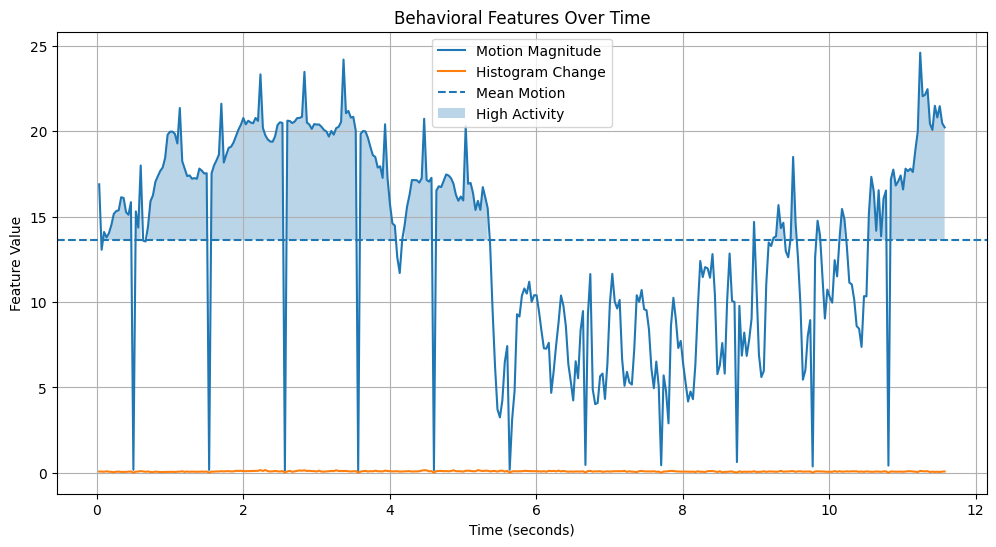

In [14]:
mean_motion = np.mean(motion_values)

plt.figure(figsize=(12,6))

# main plots
plt.plot(times, motion_values, label="Motion Magnitude")
plt.plot(times, hist_values, label="Histogram Change")

# mean line
plt.axhline(mean_motion, linestyle='--', label='Mean Motion')

# highlight high activity
high_activity = motion_values > mean_motion
plt.fill_between(
    times,
    motion_values,
    mean_motion,
    where=high_activity,
    alpha=0.3,
    label="High Activity"
)
print("Mean Motion:", np.mean(motion_values))
print("Mean Histogram Change:", np.mean(hist_values))

plt.xlabel("Time (seconds)")
plt.ylabel("Feature Value")
plt.title("Behavioral Features Over Time")
plt.legend()
plt.grid()

plt.show()

## Behavioral Interpretation

In the selected video, spikes in motion magnitude correspond to rapid movement of the animal, possibly indicating active exploration or reaction to the environment. Lower motion regions indicate relatively stable or resting states.

The histogram change also increases during some of these intervals, suggesting that visual appearance is changing along with motion.

The dashed mean-motion line helps separate relatively low-activity and high-activity periods, while the shaded regions highlight intervals of elevated motion.

However, these features are limited as they do not capture posture or detailed body dynamics and can be affected by lighting or camera movement.

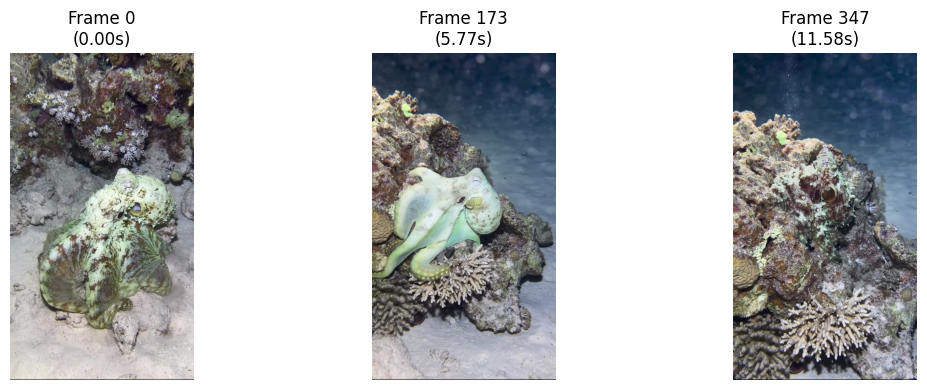

In [15]:
cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
indices = np.linspace(0, total_frames - 1, 3, dtype=int)

plt.figure(figsize=(12,4))

for i, idx in enumerate(indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 3, i + 1)
        plt.imshow(frame)
        plt.title(f"Frame {idx}\n({idx/fps:.2f}s)")
        plt.axis("off")

cap.release()
plt.tight_layout()
plt.show()

## Limitations and Future Work

### Limitations
- These features do not explicitly capture posture or body-part movement.
- Motion magnitude can be affected by camera movement or water disturbance.
- Histogram change can be influenced by lighting variation.
- These signals are useful as behavioral proxies, but they do not directly reveal internal emotional state.

### Future Work
- Optical flow for richer motion analysis
- Contour tracking for body extent and posture
- Audio integration for multi-modal inference
- Temporal models for longer behavioral sequences